# 03 — Model analysis and explanations (Version 0.6)

Version 0.6 asked three questions about the tuned model: which parts of the spectrum it uses, how
stable that answer is, and where its probabilities can be trusted. This notebook **renders the files
that `scripts/explain_model.py` already wrote** to `results/metrics/v0.6/` and `results/plots/v0.6/`.
Nothing is retrained, re-scored or recomputed here, so every number shown is the committed number.

The explained model is `v0.4.0-tuned_lightgbm-random-seed42`. The explanations were computed on the
validation rows of the `random` split only, and **no test row was re-scored** for this analysis.

If the reports are missing, regenerate them first (from the project root):
```
python scripts/explain_model.py
python scripts/explain_tables.py
```

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import pandas as pd
from IPython.display import Image, display

from src.utils import load_config, project_path

config = load_config(PROJECT_ROOT / "config.yaml")
pd.set_option("display.max_columns", 50)
DATASET = config["dataset"]["name"]
REPORTS = project_path(config["explain"]["report_dir"]) / DATASET
PLOTS = project_path(config["explain"]["plot_dir"])


def read_csv(name: str) -> pd.DataFrame:
    """A saved Version 0.6 table. Only results/ is read here; the DRIAMS data is never touched."""
    return pd.read_csv(REPORTS / name)


def read_json(name: str) -> dict:
    return json.loads((REPORTS / name).read_text(encoding="utf-8"))


def mz(frame: pd.DataFrame) -> pd.Series:
    """The m/z interval label: the only name this project gives a region."""
    return frame["mz_start"].map("{:,.0f}".format) + " – " + frame["mz_end"].map("{:,.0f}".format)


print("reports:", REPORTS.relative_to(PROJECT_ROOT), f"({len(list(REPORTS.glob('*')))} files)")
print("plots:  ", PLOTS.relative_to(PROJECT_ROOT), f"({len(list(PLOTS.glob('*.png')))} figures)")

reports: results\metrics\v0.6\ecoli_ciprofloxacin (17 files)
plots:   results\plots\v0.6 (3 figures)


## 1. What was explained

Provenance first: the explanation is only meaningful for one saved model, on one part of one split.
`test_parts_scored` records that the locked test parts were not opened to produce any of it.

In [2]:
run = read_json("run_config.json")
provenance = {
    "explained model": run["explained_model"],
    "split": run["split"],
    "rows explained": run["rows_explained"],
    "n rows explained": run["n_rows_explained"],
    "test_parts_scored": run["test_parts_scored"],
    "exact contributions (TreeSHAP)": run["exact_contributions"],
    "validation ROC AUC of that model": run["validation_roc_auc"],
    "git commit": run["git_commit"],
    "run finished": f"{run['updated']} ({run['timezone']})",
    **{f"{name} version": value for name, value in run["versions"].items()},
}
pd.Series(provenance).to_frame("value")

,value
explained model,v0.4.0-tuned_lightgbm-random-seed42
split,random
rows explained,validation
n rows explained,426
test_parts_scored,False
exact contributions (TreeSHAP),True
validation ROC AUC of that model,0.776486
git commit,1ecd579-dirty
run finished,2026-09-20 12:33:36 (India Standard Time+0530)
python version,3.12.10


## 2. Influential m/z regions

Neighbouring bins that the model uses together are merged into regions. `total_abs` is how much the
region moved predictions across the explained rows (mean absolute contribution), `towards` is the
direction a higher intensity pushes, and `standardised_difference` is the model-free resistant-minus-
susceptible difference in the same interval — a check that the region is not purely a model artefact.

A region is named by its **m/z interval only**; see the limitations at the end.

In [3]:
regions = read_csv("regions.csv")
contrast = read_csv("region_contrast.csv")
region_table = regions.merge(
    contrast[["rank", "mean_resistant", "mean_susceptible", "difference", "standardised_difference"]],
    on="rank", validate="one_to_one",
)
region_table["m/z region"] = mz(region_table)
region_table.set_index("rank")[
    ["m/z region", "n_columns", "total_abs", "total_signed", "towards", "value_correlation",
     "mean_resistant", "mean_susceptible", "standardised_difference"]
]

,m/z region,n_columns,total_abs,total_signed,towards,value_correlation,mean_resistant,mean_susceptible,standardised_difference
rank,,,,,,,,,
1,"11,771 – 11,786",5,0.570938,0.042790,resistant,0.487735,0.000728,0.000445,0.578806
2,"5,894 – 5,903",3,0.414388,0.026527,resistant,0.572906,0.000976,0.000631,0.584376
3,"8,444 – 8,453",3,0.398241,0.024527,resistant,0.817553,0.000798,0.000567,0.515184
4,"6,893 – 6,908",5,0.370919,-0.028904,resistant,0.680979,0.000676,0.000511,0.388640
5,"8,501 – 8,513",4,0.324107,-0.003227,susceptible,-0.810054,0.000469,0.000646,-0.472619
6,"10,469 – 10,481",4,0.267465,-0.023904,resistant,0.717921,0.001166,0.000708,0.331964
7,"6,809 – 6,815",2,0.189451,0.015799,susceptible,-0.554829,0.000457,0.000975,-0.384427
8,"6,866 – 6,872",2,0.182468,0.004910,susceptible,-0.859591,0.000428,0.000543,-0.340675
9,"5,855 – 5,861",2,0.170538,-0.006484,susceptible,-0.824315,0.000344,0.000449,-0.190384


## 3. Figures

The figures saved by the explanation run, shown as files. They are not redrawn here, so what is on
screen is exactly what was committed.

ecoli_ciprofloxacin_random_regions.png


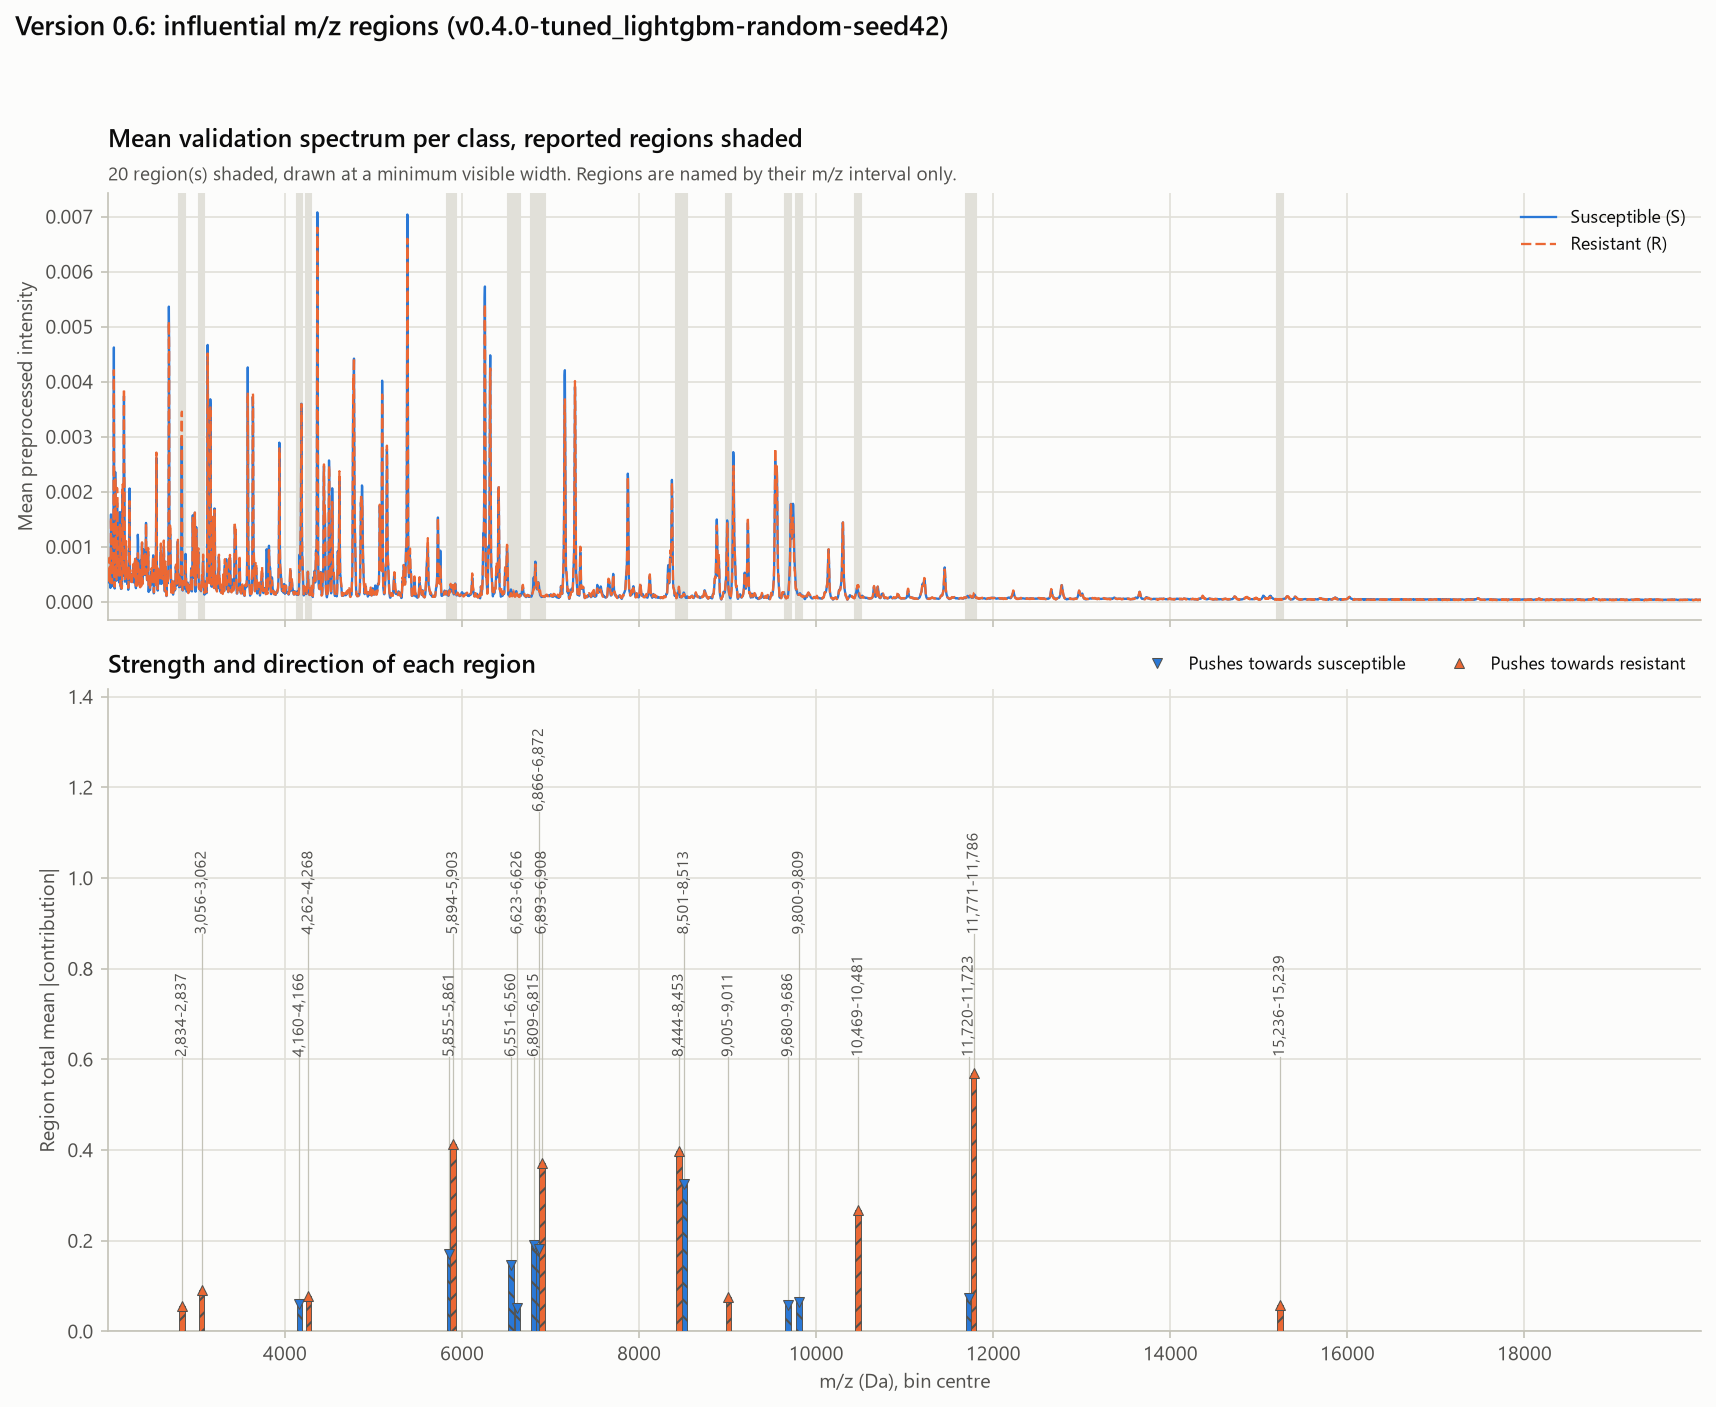

ecoli_ciprofloxacin_random_uncertainty_zones.png


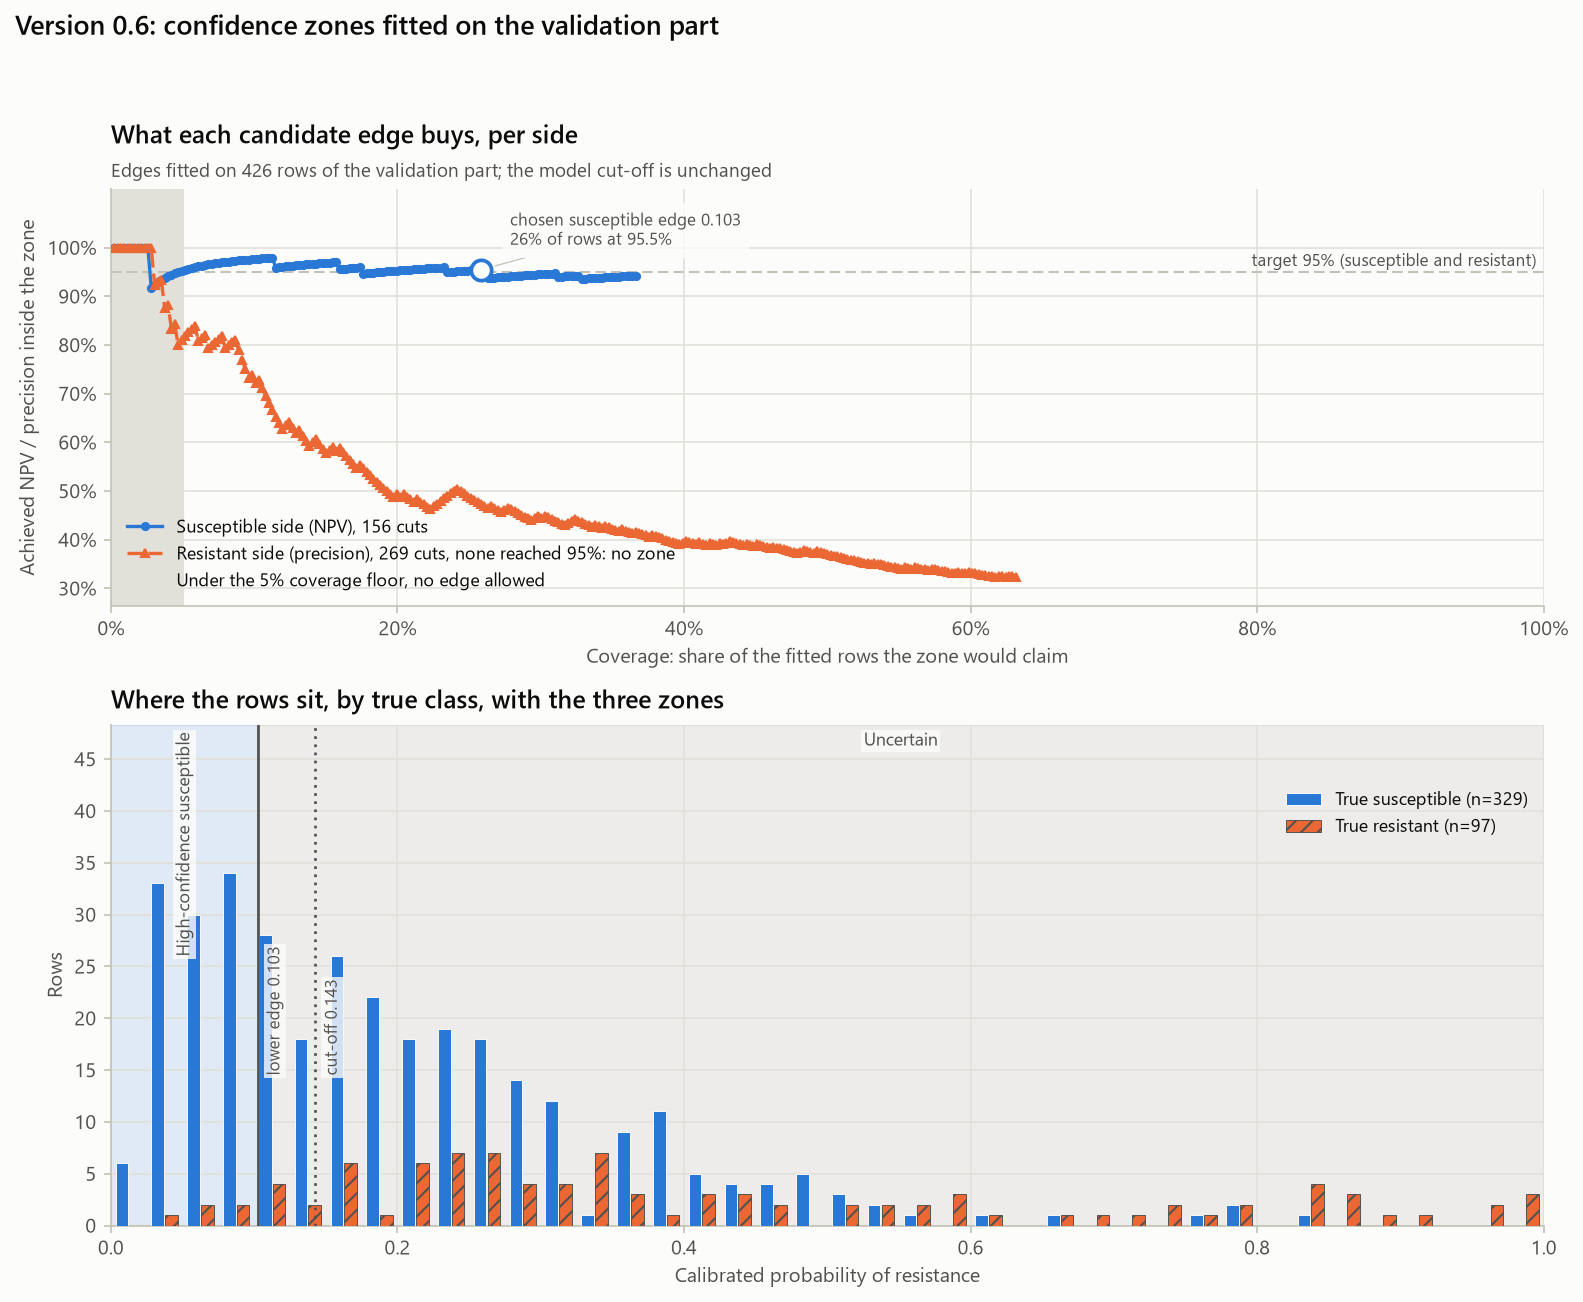

ecoli_ciprofloxacin_random_importance_agreement.png


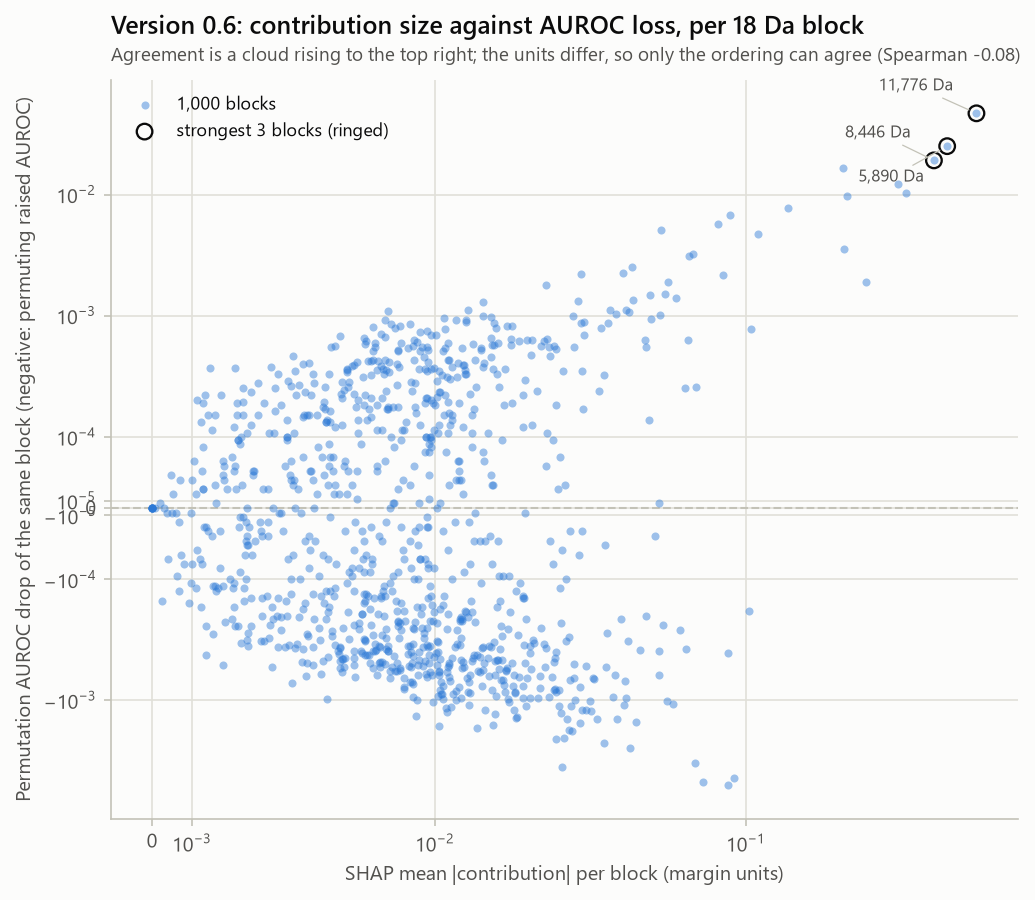

In [4]:
for name in run["plots"]:
    print(name)
    display(Image(filename=str(PLOTS / name), width=900))

## 4. What the AUROC depends on (block permutation)

This answers a **different question** from section 2. The contributions say how much a region moved
individual predictions of this fitted model. Block permutation shuffles a block of bins across rows
and measures how much validation AUROC is lost, i.e. how much the ranking of isolates depends on that
block. A region can move many individual predictions and still be replaceable, because correlated
bins elsewhere carry the same information — so the two tables are not expected to agree. How much
they actually agree is printed underneath the table, from `method_agreement` in the run config.

In [5]:
blocks = read_csv("permutation_blocks.csv")
print(f"blocks scored: {len(blocks):,} | baseline validation AUROC: {blocks['baseline_roc_auc'].iloc[0]}")
top_blocks = blocks.head(10).copy()
top_blocks["m/z block"] = mz(top_blocks)
display(top_blocks[["m/z block", "auroc_drop_mean", "auroc_drop_sd", "auroc_drop_min", "auroc_drop_max"]])
pd.Series(run["method_agreement"]).to_frame("TreeSHAP vs permutation, same model")

blocks scored: 1,000 | baseline validation AUROC: 0.7764860715069094


,m/z block,auroc_drop_mean,auroc_drop_sd,auroc_drop_min,auroc_drop_max
0,"11,774 – 11,792",0.046890,0.020753,0.020681,0.067903
1,"5,888 – 5,906",0.025106,0.013411,0.002883,0.038605
2,"8,444 – 8,462",0.019152,0.007498,0.007176,0.027011
3,"6,860 – 6,878",0.016482,0.004023,0.011970,0.022373
4,"6,896 – 6,914",0.012290,0.001596,0.010905,0.014853
5,"8,498 – 8,516",0.010334,0.006998,0.002319,0.017830
6,"6,806 – 6,824",0.009664,0.005203,0.003541,0.016357
7,"6,554 – 6,572",0.007802,0.001832,0.005797,0.009902
8,"4,160 – 4,178",0.006800,0.003178,0.002131,0.009244
9,"8,318 – 8,336",0.005672,0.002748,0.002789,0.010059


,"TreeSHAP vs permutation, same model"
spearman,-0.081635
top_k,20.000000
overlap,14.000000
overlap_fraction,0.700000


## 5. Stability: five seeds, and a shuffled-label control

`seed_agreement.csv` compares the bin rankings of every pair of the five refits; `seed_stability.csv`
asks how many of each seed's reported regions are also reported by seed 42, and where its strongest
region sits. `null_control.json` refits the same setting on shuffled training labels: whatever it
produces is what this pipeline yields when there is nothing to find.

In [6]:
agreement = read_csv("seed_agreement.csv")
stability = read_csv("seed_stability.csv")
null_control = read_json("null_control.json")

display(agreement)
display(stability)
print(f"seed pairs: {len(agreement)} | mean Spearman {agreement['spearman'].mean():.4f} "
      f"| mean top-{int(agreement['top_k'].iloc[0])} overlap {agreement['overlap'].mean():.1f}")
pd.Series(null_control).to_frame("shuffled-label control")

,seed_a,seed_b,spearman,top_k,overlap,overlap_fraction
0,42,43,0.369065,100,71,0.71
1,42,44,0.343461,100,72,0.72
2,42,45,0.365002,100,69,0.69
3,42,46,0.336037,100,67,0.67
4,43,44,0.355095,100,69,0.69
5,43,45,0.345371,100,71,0.71
6,43,46,0.346940,100,65,0.65
7,44,45,0.363776,100,70,0.70
8,44,46,0.338262,100,69,0.69
9,45,46,0.335951,100,73,0.73


,seed,n_regions,regions_shared_with_seed42,strongest_region_mz_start,strongest_region_mz_end
0,42,20,20,11771.0,11786.0
1,43,20,14,11771.0,11795.0
2,44,20,10,11771.0,11786.0
3,45,20,13,11771.0,11792.0
4,46,20,8,11771.0,11792.0


seed pairs: 10 | mean Spearman 0.3499 | mean top-100 overlap 69.6


,shuffled-label control
seed,42
fit_seconds,27.2
shuffled_labels,True
n_train,2977
null_strongest_bin,0.11211
null_mean_bin,0.00253
null_top_region_equivalent,0.445413
real_strongest_region,0.570938
real_over_null,1.281817


**What this does show.** The five refits agree on a large share of their top bins, and the strongest
region lands in the same place every time, so that region is not an accident of one seed.

**What it does not show.** The rank correlation between seed pairs is nowhere near 1 and the set of
reported regions changes from seed to seed, so the ordering below the strongest region is not
reproducible. The shuffled-label control is the blunt one: a model fitted on labels with no
relationship to the spectra still produces contributions of a similar size, so the magnitude of a
contribution is, by itself, not evidence of signal. Only the ratio printed above — and the AUROC
drops in section 4 — argue that the top region carries something real, and they argue it weakly.

## 6. Confidence zones

The rule is pre-registered in `config.yaml` (`explain.uncertainty`): a probability band is called
high-confidence only if it reaches the target rate **and** covers at least the minimum share of rows.
The edges were fitted on the validation part.

**The high-confidence resistant zone does not exist at the pre-registered target.** No cut on the
resistant side reaches the target at the required coverage, so every isolate the model leans
resistant about is reported as uncertain instead. Only the susceptible side has a zone.

The test row of the zone table is derived from the predictions stored in Version 0.4 — it is a
re-reading of a logged result, not a new scoring of the test part.

In [7]:
zones = read_json("uncertainty.json")
zone_metrics = read_csv("zone_metrics.csv")
zone_intervals = read_json("zone_intervals.json")

print(f"cut-off {zones['threshold']} | susceptible edge {zones['lower']} | resistant edge {zones['upper']}")
print(f"rule {zones['rule']} | fitted on {zones['fitted_on']} ({zones['n_fitted']} rows)")
display(pd.DataFrame(zones["sides"]).T)
display(zone_metrics.set_index("part")[
    ["n", "n_resistant", "n_zone_susceptible", "share_susceptible", "n_zone_uncertain", "share_uncertain",
     "n_zone_resistant", "share_resistant", "npv_susceptible", "precision_resistant", "accuracy_confident"]
])
pd.DataFrame(zone_intervals).T

cut-off 0.14261540693905073 | susceptible edge 0.10255963637363619 | resistant edge None
rule {'target_npv': 0.95, 'target_precision': 0.95, 'min_coverage': 0.05} | fitted on validation (426 rows)


,target,edge,n_covered,coverage,achieved,exists,best_achieved,best_edge,best_coverage
susceptible,0.95,0.10256,110,0.258216,0.954545,True,0.979167,0.05529,0.112676
resistant,0.95,None,0,0.0,NaN,False,0.84,0.670373,0.058685


,n,n_resistant,n_zone_susceptible,share_susceptible,n_zone_uncertain,share_uncertain,n_zone_resistant,share_resistant,npv_susceptible,precision_resistant,accuracy_confident
part,,,,,,,,,,,
validation,426,97,110,0.258216,316,0.741784,0,0.0,0.954545,NaN,0.954545
test (from stored predictions),856,197,213,0.248832,643,0.751168,0,0.0,0.948357,NaN,0.948357


,value,low,high,draws
share_susceptible,0.248832,0.211536,0.286064,2000.0
npv_susceptible,0.948357,0.909987,0.980861,2000.0
share_uncertain,0.751168,0.713936,0.788464,2000.0
share_resistant,0.000000,0.000000,0.000000,2000.0
precision_resistant,NaN,NaN,NaN,0.0
confident_share,0.248832,0.211536,0.286064,2000.0


Three individual explanations, one per end of the probability range. `validation_position` is the row
number inside the validation part — no identifier, and no spectrum is named.

In [8]:
examples = read_csv("examples.csv")
examples["m/z region"] = mz(examples)
examples.set_index(["example", "validation_position", "resistance_probability", "true_label", "output"])[
    ["region_rank", "m/z region", "contribution", "pushed_towards"]
]

region_rank  \
example                validation_position resistance_probability true_label output                                     
lowest probability     129                 0.011503               0          High-confidence susceptible            1   
                                                                             High-confidence susceptible            2   
                                                                             High-confidence susceptible            3   
                                                                             High-confidence susceptible            4   
                                                                             High-confidence susceptible            5   
closest to the cut-off 222                 0.142615               1          Uncertain                              1   
                                                                             Uncertain                              2   
                                                                             Uncertain                              3   
                                                                             Uncertain                              4   
                                                                             Uncertain                              5   
highest probability    10                  0.985783               1          Uncertain                              1   
                                                                             Uncertain                              2   
                                                                             Uncertain                              3   
                                                                             Uncertain                              4   
                                                                             Uncertain                              5   

                                                                                                               m/z region  \
example                validation_position resistance_probability true_label output                                         
lowest probability     129                 0.011503               0          High-confidence susceptible    6,809 – 6,815   
                                                                             High-confidence susceptible    8,447 – 8,453   
                                                                             High-confidence susceptible    5,894 – 5,903   
                                                                             High-confidence susceptible  11,780 – 11,783   
                                                                             High-confidence susceptible    8,501 – 8,513   
closest to the cut-off 222                 0.142615               1          Uncertain                      5,894 – 5,903   
                                                                             Uncertain                      8,447 – 8,453   
                                                                             Uncertain                      6,893 – 6,908   
                                                                             Uncertain                      8,504 – 8,513   
                                                                             Uncertain                    11,780 – 11,783   
highest probability    10                  0.985783               1          Uncertain                    11,771 – 11,795   
                                                                             Uncertain                      8,444 – 8,453   
                                                                             Uncertain                      5,894 – 5,903   
                                                                             Uncertain                      6,896 – 6,908   
                                                

## 7. Limitations

- **No m/z region is given a protein or peptide identity.** This project has no MS/MS confirmation
  and no independent panel, so a region is named by its m/z interval and nothing more. Attaching a
  protein name to any interval above would be a guess dressed as a result.
- One species, one antibiotic, one split, one model. The regions are a property of *this* fitted
  model on *this* data, not a property of ciprofloxacin resistance.
- Everything is measured on validation rows. This is not a test-set result, and the zone edges were
  fitted on the same rows they are summarised on, so the validation zone numbers are optimistic; the
  test row is the honest one, and it is a re-reading of stored predictions.
- The methods disagree (section 4), the seeds agree only in part (section 5), and the shuffled-label
  control sits close to the real model (section 5). The region list is a hypothesis to be tested with
  chemistry, not a finding.
- **Research prototype.** Nothing here is a clinically validated diagnostic, and nothing here
  supports a treatment decision for any patient.